In [ ]:
#Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Extracting ZIP
import zipfile
zip_path = "/content/drive/My Drive/Loan Approval Prediction.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset/")

***Import Libraries***

In [ ]:
# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss
)
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

***Load Dataset***

In [ ]:
# Step 2: Load Dataset

df = pd.read_csv('/content/dataset/loan_data_1.csv')
# Show first 5 rows
df.head()

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
1,1,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y
2,2,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y
3,3,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y
4,4,LP001013,Male,Yes,0,Not Graduate,No,2333.0,1516.0,95.0,360.0,1.0,Urban,Y


In [42]:
# Step 3: Dataset Structure

print('Dataset Shape :', df.shape)
print('\nDataset Information:')
print(df.info())

Dataset Shape : (381, 12)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             381 non-null    int64  
 1   Married            381 non-null    int64  
 2   Dependents         381 non-null    int64  
 3   Education          381 non-null    int64  
 4   Self_Employed      381 non-null    int64  
 5   ApplicantIncome    381 non-null    float64
 6   CoapplicantIncome  381 non-null    float64
 7   LoanAmount         381 non-null    float64
 8   Loan_Amount_Term   381 non-null    float64
 9   Credit_History     381 non-null    float64
 10  Property_Area      381 non-null    int64  
 11  Loan_Status        381 non-null    int64  
dtypes: float64(5), int64(7)
memory usage: 35.8 KB
None


***Handle Missing Values***

In [ ]:
# Step 4: Check Missing Values

print(df.isnull().sum())

Unnamed: 0            0
Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             6
Self_Employed        21
ApplicantIncome      12
CoapplicantIncome    18
LoanAmount            8
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64


In [ ]:
# Step 5: Remove Unnecessary Columns

if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

if 'Loan_ID' in df.columns:
    df.drop('Loan_ID', axis=1, inplace=True)

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
1,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y
2,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y
3,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y
4,Male,Yes,0,Not Graduate,No,2333.0,1516.0,95.0,360.0,1.0,Urban,Y


In [ ]:
# Step 6: Fill Missing Values

# Separate categorical and numerical columns
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

# Fill categorical missing values with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill numerical missing values with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Check again
print(df.isnull().sum())

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [ ]:
# Step 7: Check Target Label

print(df['Loan_Status'].value_counts())

Loan_Status
Y    271
N    110
Name: count, dtype: int64


***Encode Categorical Data***

In [ ]:
# Step 8: Encode Target Labels

label_encoder = LabelEncoder()
df['Loan_Status'] = label_encoder.fit_transform(df['Loan_Status'])
print(df['Loan_Status'].value_counts())

Loan_Status
1    271
0    110
Name: count, dtype: int64


In [ ]:
# Step 9: Encode Categorical Features

categorical_columns = df.select_dtypes(include='object').columns
le = LabelEncoder()

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        1           1          0              0           4583.0   
1       1        1           0          0              1           3000.0   
2       1        1           0          1              0           2583.0   
3       1        0           0          0              0           6000.0   
4       1        1           0          1              0           2333.0   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0             1508.0       128.0             360.0             1.0   
1                0.0        66.0             360.0             1.0   
2             2358.0       120.0             360.0             1.0   
3                0.0       141.0             360.0             1.0   
4             1516.0        95.0             360.0             1.0   

   Property_Area  Loan_Status  
0              0            0  
1              2            1  
2              2    

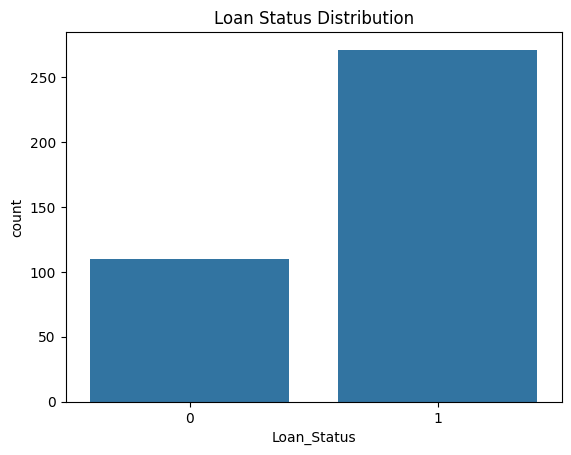

Loan_Status
1    271
0    110
Name: count, dtype: int64


In [ ]:
# Step 10: Check Dataset Balance

sns.countplot(x=df['Loan_Status'])
plt.title('Loan Status Distribution')
plt.show()

print(df['Loan_Status'].value_counts())

In [ ]:
# Step 11: Feature and Target Separation

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
print(X.shape)
print(y.shape)

(381, 11)
(381,)


***Balance and Scale Data***

In [ ]:
# Step 12: Handle Imbalanced Data Using SMOTE

smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

print(pd.Series(y).value_counts())

Loan_Status
0    271
1    271
Name: count, dtype: int64


In [ ]:
# Step 13: Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

***Split Train and Test Data***

In [ ]:
# Step 14: Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training Shape :', X_train.shape)
print('Testing Shape :', X_test.shape)

Training Shape : (433, 11)
Testing Shape : (109, 11)


***Train Logistic Regression Model and Predict Output***

In [ ]:
# Step 15: Logistic Regression Model

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
print('Model Training Completed')

# Predictions

lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)

lr_train_prob = lr_model.predict_proba(X_train)
lr_test_prob = lr_model.predict_proba(X_test)

Model Training Completed


***Evaluate Model Accuracy***

In [ ]:
# Step 17: Model Evaluation

lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_test_acc = accuracy_score(y_test, lr_test_pred)

lr_train_loss = log_loss(y_train, lr_train_prob)
lr_test_loss = log_loss(y_test, lr_test_prob)

print('Training Accuracy :', round(lr_train_acc * 100, 2), '%')
print('Testing Accuracy  :', round(lr_test_acc * 100, 2), '%')

print('Training Loss :', round(lr_train_loss * 100, 2), '%')
print('Testing Loss  :', round(lr_test_loss * 100, 2), '%')

print('\nClassification Report :\n')
print(classification_report(y_test, lr_test_pred))

Training Accuracy : 82.22 %
Testing Accuracy  : 83.49 %
Training Loss : 42.31 %
Testing Loss  : 39.81 %

Classification Report :

              precision    recall  f1-score   support

           0       0.95      0.71      0.81        55
           1       0.76      0.96      0.85        54

    accuracy                           0.83       109
   macro avg       0.86      0.84      0.83       109
weighted avg       0.86      0.83      0.83       109



***Check Overfitting/Underfitting***

In [ ]:
#Step 17: Overfitting and Underfitting Check

print("Training Accuracy :", round(lr_train_acc * 100, 2), "%")
print("Testing Accuracy  :", round(lr_test_acc * 100, 2), "%")

# Condition Checking
difference = abs(lr_train_acc - lr_test_acc)
print("\nAccuracy Difference :", round(difference * 100, 2), "%")

# Model Analysis
if lr_train_acc > 0.95 and difference > 0.10:
    print("\nModel is Overfitting")

elif lr_train_acc < 0.70 and lr_test_acc < 0.70:
    print("\nModel is Underfitting")

else:
    print("\nModel is Well-Fitted")

Training Accuracy : 82.22 %
Testing Accuracy  : 83.49 %

Accuracy Difference : 1.27 %

Model is Well-Fitted


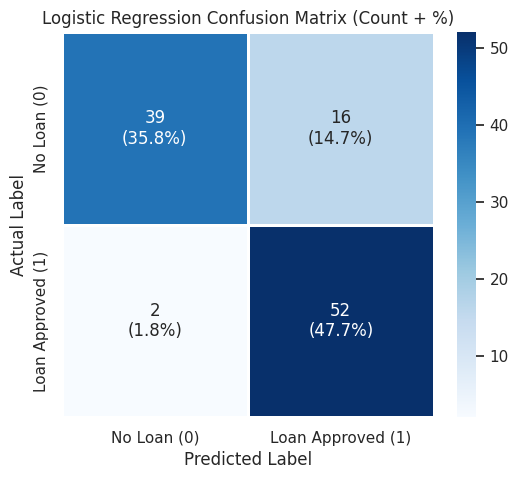

In [38]:
# Step 18: Confusion Matrix (Counts + Percentages)

cm = confusion_matrix(y_test, lr_test_pred)

cm_percent = cm.astype('float') / cm.sum() * 100

labels = [
    [f"{cm[0,0]}\n({cm_percent[0,0]:.1f}%)", f"{cm[0,1]}\n({cm_percent[0,1]:.1f}%)"],
    [f"{cm[1,0]}\n({cm_percent[1,0]:.1f}%)", f"{cm[1,1]}\n({cm_percent[1,1]:.1f}%)"]
]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    linewidths=1,
    linecolor='white'
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Logistic Regression Confusion Matrix (Count + %)')
plt.xticks([0.5, 1.5], ['No Loan (0)', 'Loan Approved (1)'])
plt.yticks([0.5, 1.5], ['No Loan (0)', 'Loan Approved (1)'])

plt.show()

***Plot Accuracy Graph***

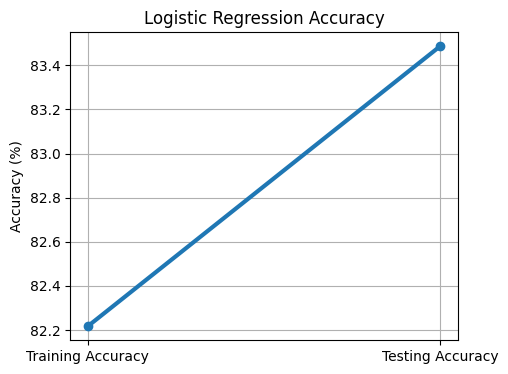

In [ ]:
# Step 19: Logistic Regression Accuracy Line Graph

accuracy_values = [
    lr_train_acc * 100,
    lr_test_acc * 100
]
labels = ['Training Accuracy', 'Testing Accuracy']
plt.figure(figsize=(5,4))
plt.plot(
    labels,
    accuracy_values,
    marker='o',
    linewidth=3
)
plt.title('Logistic Regression Accuracy')
plt.ylabel('Accuracy (%)')

plt.grid(True)
plt.show()

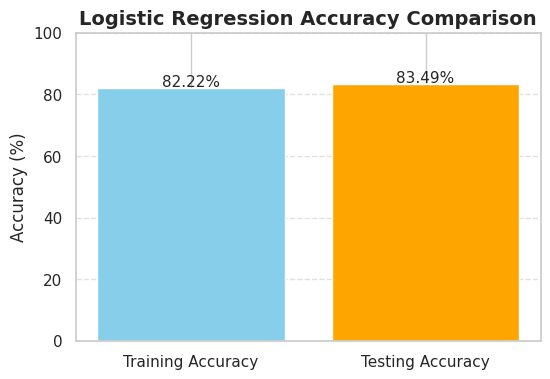

In [39]:
# Step 19: Logistic Regression Accuracy Visualization

accuracy_values = [
    lr_train_acc * 100,
    lr_test_acc * 100
]

labels = ['Training Accuracy', 'Testing Accuracy']
plt.figure(figsize=(6,4))
bars = plt.bar(labels, accuracy_values, color=['skyblue', 'orange'])

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.2f}%',
        ha='center',
        fontsize=11
    )

plt.title('Logistic Regression Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

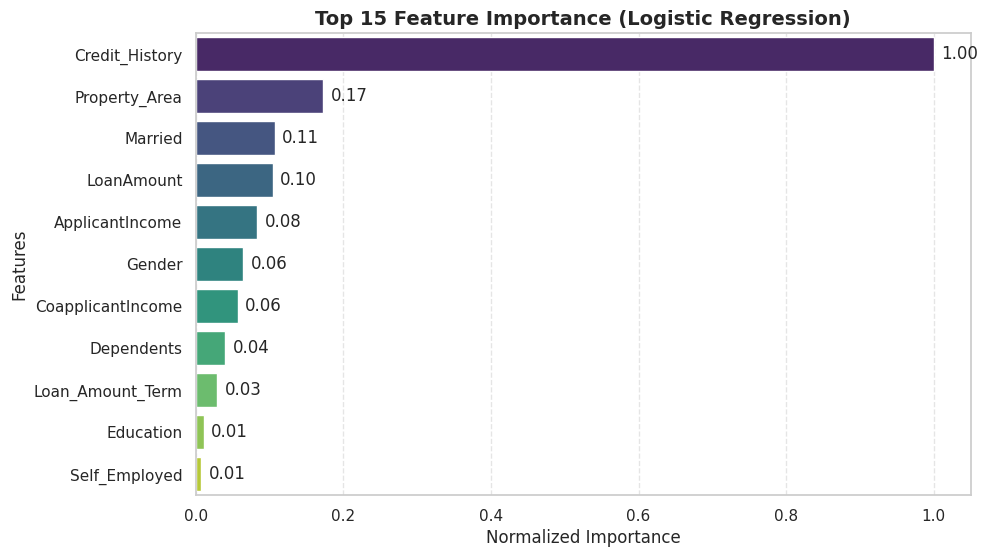

In [41]:
# Step 20: Improved Feature Importance (Logistic Regression)

# Absolute coefficients
importance = np.abs(lr_model.coef_[0])
feature_names = X.columns
# Create dataframe
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
# Sort and take top 15 features for clarity
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(15)
# Normalize for better interpretability (0–1 scale)
feature_df['Importance'] = feature_df['Importance'] / feature_df['Importance'].max()
plt.figure(figsize=(10,6))
ax = sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df,
    palette='viridis'
)
# Add value labels
for i, v in enumerate(feature_df['Importance']):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center')

plt.title('Top 15 Feature Importance (Logistic Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Normalized Importance')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

***Save and Test Model***

In [ ]:
# Step 1: Save Model

import joblib
joblib.dump(lr_model, 'loan_approval_logistic_regression.pkl')
print('Model Saved Successfully')

Model Saved Successfully


In [ ]:
# Step 2: New Applicant Data

Ali= {
    'Gender': ['Male'],
    'Married': ['Yes'],
    'Dependents': ['1'],
    'Education': ['Graduate'],
    'Self_Employed': ['No'],
    'ApplicantIncome': [5000],
    'CoapplicantIncome': [2000],
    'LoanAmount': [150],
    'Loan_Amount_Term': [360],
    'Credit_History': [1.0],
    'Property_Area': ['Urban']
}

# Sample Data For Loan Not Approved Prediction

Haris= {
    'Gender': ['Male'],
    'Married': ['No'],
    'Dependents': ['3+'],
    'Education': ['Not Graduate'],
    'Self_Employed': ['Yes'],
    'ApplicantIncome': [1200],
    'CoapplicantIncome': [0],
    'LoanAmount': [300],
    'Loan_Amount_Term': [120],
    'Credit_History': [0.0],
    'Property_Area': ['Rural']
}

Ali = pd.DataFrame(Ali)
print(Ali)

print("\n")

Haris = pd.DataFrame(Haris)
print(Haris)

  Gender Married Dependents Education Self_Employed  ApplicantIncome  \
0   Male     Yes          1  Graduate            No             5000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0               2000         150               360             1.0   

  Property_Area  
0         Urban  


  Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0   Male      No         3+  Not Graduate           Yes             1200   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                  0         300               120             0.0   

  Property_Area  
0         Rural  


In [ ]:
# Step 3: Encode New Data

categorical_columns = Ali.select_dtypes(include='object').columns
le = LabelEncoder()

for col in categorical_columns:
    Ali[col] = le.fit_transform(Ali[col])
print(Ali)



categorical_columns_2 = Haris.select_dtypes(include='object').columns
le_2 = LabelEncoder()

for col in categorical_columns:
    Haris[col] = le.fit_transform(Haris[col])
print(Haris)

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       0        0           0          0              0             5000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0               2000         150               360             1.0   

   Property_Area  
0              0  
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       0        0           0          0              0             1200   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                  0         300               120             0.0   

   Property_Area  
0              0  


In [ ]:
# Step 4: Feature Scaling

new_scaled = scaler.transform(Ali)
new_scaled_2 = scaler.transform(Haris)

In [ ]:
# Step 5: Prediction and output

prediction = lr_model.predict(new_scaled)
print("Loan Approval Prediction for Ali :", prediction)
if prediction[0] == 1:
    print("So, Loan is Approved")
else:
    print("So, Loan is Rejected")

print("\n")

prediction = lr_model.predict(new_scaled_2)
print("Loan Approval Prediction for Haris:", prediction)
if prediction[0] == 1:
    print("So, Loan is Approved")
else:
    print("So, Loan is Rejected")

Loan Approval Prediction for Ali : [1]
So, Loan is Approved


Loan Approval Prediction for Haris: [0]
So, Loan is Rejected


***Conclusion***

In [ ]:

print('Conclusion :')

print('The Loan Approval Prediction model was successfully implemented using Logistic Regression.')

print('Missing values and categorical data were properly handled.')

print('SMOTE was used to balance the dataset and StandardScaler was used for feature scaling.')

print('The model achieved good training and testing accuracy, showing effective loan approval prediction performance.')

Conclusion :
The Loan Approval Prediction model was successfully implemented using Logistic Regression.
Missing values and categorical data were properly handled.
SMOTE was used to balance the dataset and StandardScaler was used for feature scaling.
The model achieved good training and testing accuracy, showing effective loan approval prediction performance.
